# Border strips and nighttime lights

Buffer the shared border by 50 km, clip the ethnic polygons to it, then dissolve so each ethnicity-country side is one geometry. Without the dissolve, zonal_stats returns one row per polygon fragment and the panel silently doubles.

**Expected:** 12 groups keep a buffer, 31 polygons before the dissolve, 24 units after. Groups 532 and 1023 have no shared border; 134, 789 and 829 do not reach the strip.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

import config
import buffer, ntl

import figures
figures.setup()

Open Sans not found, falling back to DejaVu Sans


In [2]:
group_ids = pd.read_csv(config.WORK / 'clean_did_groups.csv')['G1ID'].tolist()
buffers, dropped = buffer.run(group_ids)

buffer CRS: ESRI:102023, width 50 km

    AO -> AO via FIPS_10: Angola
    CG -> CG via FIPS_10: Democratic Republic of the Congo
  124 Bambundu (AO/CG): ok, 2 polygons
    AO -> AO via FIPS_10: Angola
    ZA -> ZA via FIPS_10: Zambia
  134 Bankoya and Wambuela (AO/ZA): only [] reaches the strip
    ET -> ET via FIPS_10: Ethiopia
    SU -> SU via FIPS_10: Sudan
  173 Berta (ET/SU): ok, 2 polygons
    CM -> CM via FIPS_10: Cameroon
    NI -> NI via FIPS_10: Nigeria
  224 Bute (CM/NI): ok, 2 polygons
    CD -> CD via FIPS_10: Chad
    SU -> SU via FIPS_10: Sudan
  321 Dago (CD/SU): ok, 2 polygons
    CM -> CM via FIPS_10: Cameroon
    NI -> NI via FIPS_10: Nigeria
  503 Jukun and Idoma (CM/NI): ok, 5 polygons
    SU -> SU via FIPS_10: Sudan
    UG -> UG via FIPS_10: Uganda
  532 Karamojo (SU/UG): no shared border
    ET -> ET via FIPS_10: Ethiopia
    SU -> SU via FIPS_10: Sudan
  574 Koma (ET/SU): ok, 4 polygons
    CM -> CM via FIPS_10: Cameroon
    NI -> NI via FIPS_10: Nigeria
  685 

In [3]:
buffers[['G1ID', 'FIPS_CNTRY', 'area_km2']].round(0)

,G1ID,FIPS_CNTRY,area_km2
0,124,AO,5512.0
1,124,CG,2454.0
2,173,ET,9509.0
3,173,SU,5551.0
4,224,CM,1742.0
5,224,NI,323.0
6,321,CD,386.0
7,321,SU,200.0
8,503,CM,2868.0
9,503,NI,8240.0


In [4]:
import geopandas as gpd

crs = buffer.buffer_crs()
countries = gpd.read_file(config.COUNTRIES_10M).to_crs(crs)
greg_all = gpd.read_file(config.GREG_SHP).to_crs(crs)

rows = []
for gid in sorted(buffers["G1ID"].unique()):
    strict = greg_all[greg_all["G1ID"] == gid]
    wide = greg_all[(greg_all["G1ID"] == gid)
                    | (greg_all["G2ID"] == gid)
                    | (greg_all["G3ID"] == gid)]
    if len(wide) == len(strict):
        continue

    fips = sorted(strict["FIPS_CNTRY"].unique())
    fips_wide = sorted(wide["FIPS_CNTRY"].unique())
    print(f"{gid}: {len(strict)} -> {len(wide)} polygons, "
          f"countries {fips} -> {fips_wide}")
    if fips_wide != fips:
        print("  !! country set changes, sample construction affected")
        continue

    border = buffer.shared_border(countries, fips[0], fips[1])
    for label, polys in [("strict", strict), ("wide", wide)]:
        kept, _ = buffer.clip_group(polys, border, fips[0], fips[1])
        if not kept:
            continue
        g = gpd.GeoDataFrame(kept, crs=crs).dissolve(by="FIPS_CNTRY")
        for f, a in (g.geometry.area / 1e6).items():
            rows.append({"G1ID": gid, "side": f, "spec": label, "km2": round(a, 1)})

out = (pd.DataFrame(rows)
       .pivot_table(index=["G1ID", "side"], columns="spec", values="km2"))
out["ratio"] = (out["wide"] / out["strict"]).round(3)
print()
print(out.to_string())

224: 2 -> 3 polygons, countries ['CM', 'NI'] -> ['CM', 'NI']
503: 8 -> 9 polygons, countries ['CM', 'NI'] -> ['CM', 'NI']
1095: 3 -> 4 polygons, countries ['CM', 'NI'] -> ['CM', 'NI']
1192: 6 -> 8 polygons, countries ['AO', 'ZA'] -> ['AO', 'ZA']

spec       strict    wide  ratio
G1ID side                       
224  CM    1741.9  1741.9  1.000
     NI     323.3   323.3  1.000
503  CM    2867.9  2867.9  1.000
     NI    8240.2  9417.9  1.143
1095 CM    1550.7  1550.7  1.000
     NI     222.4   222.4  1.000
1192 AO    7459.3  7459.3  1.000
     ZA    3852.0  3852.0  1.000


In [5]:
stored = pd.read_csv(config.WORK / "buffer_areas.csv")
stored = stored.set_index(["G1ID", "FIPS_CNTRY"])["area_km2"].round(1)
chk = out.join(stored.rename_axis(["G1ID", "side"]).rename("stored"))
print(chk[["strict", "stored", "wide", "ratio"]].to_string())

           strict  stored    wide  ratio
G1ID side                               
224  CM    1741.9  1741.9  1741.9  1.000
     NI     323.3   323.3   323.3  1.000
503  CM    2867.9  2867.9  2867.9  1.000
     NI    8240.2  8240.2  9417.9  1.143
1095 CM    1550.7  1550.7  1550.7  1.000
     NI     222.4   222.4   222.4  1.000
1192 AO    7459.3  7459.3  7459.3  1.000
     ZA    3852.0  3852.0  3852.0  1.000


In [6]:
lights = ntl.run(buffers)
lights.head()

rasters found: 34
  2013 (simVIIRS)
  1992 (calDMSP)
  1993 (calDMSP)
  1994 (calDMSP)
  1995 (calDMSP)
  1996 (calDMSP)
  1997 (calDMSP)
  1998 (calDMSP)
  1999 (calDMSP)
  2000 (calDMSP)
  2001 (calDMSP)
  2002 (calDMSP)
  2003 (calDMSP)
  2004 (calDMSP)
  2005 (calDMSP)
  2006 (calDMSP)
  2007 (calDMSP)
  2008 (calDMSP)
  2009 (calDMSP)
  2010 (calDMSP)
  2011 (calDMSP)
  2012 (calDMSP)
  2013 (calDMSP)
  2014 (simVIIRS)
  2015 (simVIIRS)
  2016 (simVIIRS)
  2017 (simVIIRS)
  2018 (simVIIRS)
  2019 (simVIIRS)
  2020 (simVIIRS)
  2021 (simVIIRS)
  2022 (simVIIRS)
  2023 (simVIIRS)
  2024 (simVIIRS)
missing radiance values: 0
largest pixel count variation:
          min   max  spread_pct
unit_id                        
1179_SO    79    83    5.063291
1192_ZA  4861  4944    1.707468
321_CD    478   485    1.464435
503_CM   3577  3603    0.726866
124_CG   3081  3101    0.649140


,G1ID,FIPS_CNTRY,unit_id,name,year,source,ntl_mean,ntl_count,ln_ntl
0,1095,CM,1095_CM,Tikar,1992,calDMSP,0.0,1944,-4.60517
1,1095,CM,1095_CM,Tikar,1993,calDMSP,0.0,1944,-4.60517
2,1095,CM,1095_CM,Tikar,1994,calDMSP,0.0,1944,-4.60517
3,1095,CM,1095_CM,Tikar,1995,calDMSP,0.0,1944,-4.60517
4,1095,CM,1095_CM,Tikar,1996,calDMSP,0.0,1944,-4.60517


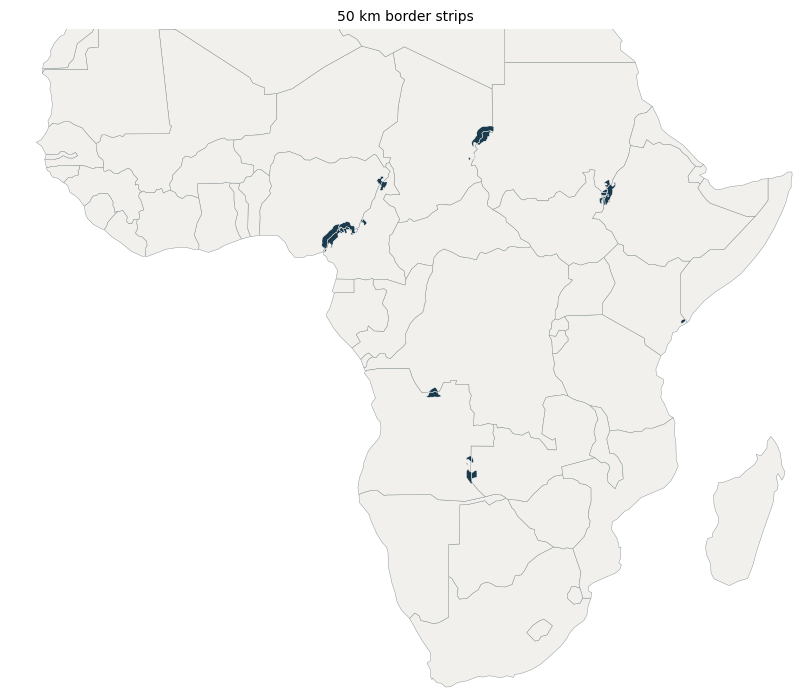

In [7]:
world = gpd.read_file(config.COUNTRIES_110M)
africa = world[world["CONTINENT"] == "Africa"]

ax = africa.plot(figsize=(8, 8), color="#F2F0EC", edgecolor=config.GREY, lw=0.3)
buffers.plot(ax=ax, color=config.NAVY, edgecolor="white", lw=0.3)
ax.set_xlim(-20, 52)
ax.set_ylim(-35, 25)
ax.set_axis_off()
ax.set_title("50 km border strips")
plt.show()

In [8]:
crs = buffer.buffer_crs()
countries = gpd.read_file(config.COUNTRIES_10M).to_crs(crs)
greg_all = gpd.read_file(config.GREG_SHP).to_crs(crs)

rows = []
for gid in sorted(buffers["G1ID"].unique()):
    strict = greg_all[greg_all["G1ID"] == gid]
    fips = sorted(strict["FIPS_CNTRY"].unique())
    name = strict["G1LONGNAM"].iloc[0]

    polys = greg_all[(greg_all["G1ID"] == gid)
                     | (greg_all["G2ID"] == gid)
                     | (greg_all["G3ID"] == gid)]
    polys = polys[polys["FIPS_CNTRY"].isin(fips)]

    border = buffer.shared_border(countries, fips[0], fips[1])
    kept, sides = buffer.clip_group(polys, border, fips[0], fips[1])
    if len(sides) < 2:
        print(f"  {gid} {name}: only {sorted(sides)} reaches the strip")
        continue
    for r in kept:
        r = r.copy()
        r["G1ID"] = gid          
        r["G1LONGNAM"] = name
        rows.append(r)

wide = (gpd.GeoDataFrame(rows, crs=crs)
        .dissolve(by=["G1ID", "FIPS_CNTRY"], aggfunc="first").reset_index())
wide["area_km2"] = wide.geometry.area / 1e6
wide["unit_id"] = wide["G1ID"].astype(str) + "_" + wide["FIPS_CNTRY"]
wide = wide.to_crs(4326)

chk = wide[["unit_id", "area_km2"]].merge(
    buffers[["unit_id", "area_km2"]], on="unit_id", suffixes=("_wide", "_strict"))
chk["ratio"] = (chk["area_km2_wide"] / chk["area_km2_strict"]).round(3)
print(f"units: {len(wide)}, changed: {(chk['ratio'] != 1.0).sum()}")
print(chk[chk["ratio"] != 1.0].to_string(index=False))

units: 24, changed: 1
unit_id  area_km2_wide  area_km2_strict  ratio
 503_NI    9417.921897      8240.172124  1.143


In [9]:
lights_wide = ntl.add_outcome(ntl.extract(wide))
lights_wide.to_csv(config.WORK / "ntl_by_unit_year_wide.csv", index=False)
wide.drop(columns="geometry").to_csv(config.WORK / "buffer_areas_wide.csv", index=False)
print(f"{len(lights_wide)} unit-years written")

rasters found: 34
  2013 (simVIIRS)
  1992 (calDMSP)
  1993 (calDMSP)
  1994 (calDMSP)
  1995 (calDMSP)
  1996 (calDMSP)
  1997 (calDMSP)
  1998 (calDMSP)
  1999 (calDMSP)
  2000 (calDMSP)
  2001 (calDMSP)
  2002 (calDMSP)
  2003 (calDMSP)
  2004 (calDMSP)
  2005 (calDMSP)
  2006 (calDMSP)
  2007 (calDMSP)
  2008 (calDMSP)
  2009 (calDMSP)
  2010 (calDMSP)
  2011 (calDMSP)
  2012 (calDMSP)
  2013 (calDMSP)
  2014 (simVIIRS)
  2015 (simVIIRS)
  2016 (simVIIRS)
  2017 (simVIIRS)
  2018 (simVIIRS)
  2019 (simVIIRS)
  2020 (simVIIRS)
  2021 (simVIIRS)
  2022 (simVIIRS)
  2023 (simVIIRS)
  2024 (simVIIRS)
792 unit-years written


In [10]:
from shapely.ops import unary_union
from shapely.validation import make_valid

crs = buffer.buffer_crs()
ne = gpd.read_file(config.COUNTRIES_10M).to_crs(crs)

col = next(c for c in ("ADMIN", "NAME_EN", "NAME", "SOVEREIGNT") if c in ne.columns)
south = ne[ne[col].astype(str).str.contains("South Sudan", case=False, na=False)]
print(f"South Sudan matched on {col}: {south[col].tolist()}")
south_geom = make_valid(unary_union(south.geometry))

rows = []
for _, r in buffers.to_crs(crs).iterrows():
    geom = make_valid(r.geometry)
    overlap = geom.intersection(south_geom)
    rows.append({"unit_id": r["unit_id"], "G1ID": r["G1ID"],
                 "FIPS_CNTRY": r["FIPS_CNTRY"],
                 "area_km2": geom.area / 1e6,
                 "in_south_sudan_km2": overlap.area / 1e6,
                 "share": overlap.area / geom.area if geom.area else 0.0})

ss = pd.DataFrame(rows).sort_values("share", ascending=False)
ss.to_csv(config.WORK / "south_sudan_overlap.csv", index=False)
print()
print(ss.round(4).to_string(index=False))

South Sudan matched on ADMIN: ['South Sudan']

unit_id  G1ID FIPS_CNTRY   area_km2  in_south_sudan_km2  share
 173_SU   173         SU  5551.1804           1881.3431 0.3389
 574_SU   574         SU  2118.7207            603.7556 0.2850
 124_AO   124         AO  5511.5472              0.0000 0.0000
 685_NI   685         NI  2786.4420              0.0000 0.0000
1243_CD  1243         CD 14601.5001              0.0000 0.0000
1192_ZA  1192         ZA  3852.0112              0.0000 0.0000
1192_AO  1192         AO  7459.3084              0.0000 0.0000
1179_SO  1179         SO    64.5571              0.0000 0.0000
1179_KE  1179         KE  1232.8981              0.0000 0.0000
1101_NI  1101         NI 14046.3014              0.0000 0.0000
1101_CM  1101         CM  8848.2325              0.0000 0.0000
1095_NI  1095         NI   222.4200              0.0000 0.0000
1095_CM  1095         CM  1550.7139              0.0000 0.0000
 685_CM   685         CM  3705.1537              0.0000 0.0000
 124_CG 

In [11]:
import numpy as np
from rasterstats import zonal_stats

def share_above(threshold):
    def f(masked):
        if masked.count() == 0:
            return None
        return float((masked.compressed() > threshold).mean())
    return f

rows = []
for path in ntl.raster_files():
    year, source = ntl.parse_filename(path)
    if year is None:
        continue
    stats = zonal_stats(
        buffers, str(path), stats=["mean", "count", "sum"],
        add_stats={"lit0": share_above(0), "lit1": share_above(1),
                   "lit5": share_above(5)},
        nodata=-9999, all_touched=False,
    )
    for unit, s in zip(buffers.itertuples(), stats):
        rows.append({"G1ID": unit.G1ID, "FIPS_CNTRY": unit.FIPS_CNTRY,
                     "unit_id": unit.unit_id,
                     "name": getattr(unit, "G1LONGNAM", ""),
                     "year": year, "source": source,
                     "ntl_mean": s["mean"], "ntl_count": s["count"],
                     "ntl_sum": s["sum"],
                     "lit0": s["lit0"], "lit1": s["lit1"], "lit5": s["lit5"]})
    print(f"  {year} ({source})")

alt = pd.DataFrame(rows)
alt = alt[~((alt["year"] == 2013) & (alt["source"] == "simVIIRS"))]
alt = alt.sort_values(["unit_id", "year"]).reset_index(drop=True)
alt.to_csv(config.WORK / "ntl_alt_outcomes.csv", index=False)

print()
print(alt[["ntl_mean", "ntl_sum", "lit0", "lit1", "lit5"]].describe().round(4).to_string())
print()
print("share of unit-years with no lit pixel at all:",
      round(float((alt["lit0"] == 0).mean()), 4))

rasters found: 34
  2013 (simVIIRS)
  1992 (calDMSP)
  1993 (calDMSP)
  1994 (calDMSP)
  1995 (calDMSP)
  1996 (calDMSP)
  1997 (calDMSP)
  1998 (calDMSP)
  1999 (calDMSP)
  2000 (calDMSP)
  2001 (calDMSP)
  2002 (calDMSP)
  2003 (calDMSP)
  2004 (calDMSP)
  2005 (calDMSP)
  2006 (calDMSP)
  2007 (calDMSP)
  2008 (calDMSP)
  2009 (calDMSP)
  2010 (calDMSP)
  2011 (calDMSP)
  2012 (calDMSP)
  2013 (calDMSP)
  2014 (simVIIRS)
  2015 (simVIIRS)
  2016 (simVIIRS)
  2017 (simVIIRS)
  2018 (simVIIRS)
  2019 (simVIIRS)
  2020 (simVIIRS)
  2021 (simVIIRS)
  2022 (simVIIRS)
  2023 (simVIIRS)
  2024 (simVIIRS)

       ntl_mean     ntl_sum      lit0      lit1      lit5
count  792.0000    792.0000  792.0000  792.0000  792.0000
mean     0.2436   1085.5253    0.0291    0.0291    0.0284
std      0.7138   3481.1933    0.0785    0.0785    0.0787
min      0.0000      0.0000    0.0000    0.0000    0.0000
25%      0.0000      0.0000    0.0000    0.0000    0.0000
50%      0.0000      0.0000    0.0000    0.

In [12]:
main_groups = pd.read_csv(config.WORK / "pair_panel.csv")["G1ID"].unique().tolist()
original_km = config.BUFFER_KM

for km in (25, 100):
    config.BUFFER_KM = km
    b, dropped_km = buffer.build(group_ids, verbose=False)
    b = b[b["G1ID"].isin(main_groups)].reset_index(drop=True)
    print(f"\n{km} km: {b['G1ID'].nunique()} of {len(main_groups)} main groups kept")

    lights_km = ntl.add_outcome(ntl.extract(b))
    lights_km.to_csv(config.WORK / f"ntl_by_unit_year_{km}km.csv", index=False)
    b.drop(columns="geometry").to_csv(
        config.WORK / f"buffer_areas_{km}km.csv", index=False)

config.BUFFER_KM = original_km
print(f"\nBUFFER_KM back to {config.BUFFER_KM}")

buffer CRS: ESRI:102023, width 25 km

  124 Bambundu (AO/CG): ok, 2 polygons
  134 Bankoya and Wambuela (AO/ZA): only [] reaches the strip
  173 Berta (ET/SU): ok, 2 polygons
  224 Bute (CM/NI): ok, 2 polygons
  321 Dago (CD/SU): only [] reaches the strip
  503 Jukun and Idoma (CM/NI): ok, 4 polygons
  532 Karamojo (SU/UG): no shared border
  574 Koma (ET/SU): ok, 2 polygons
  685 Mandara (incl. Matakam, Gidar) (CM/NI): ok, 2 polygons
  789 Murle (ET/SU): only [] reaches the strip
  829 Nuer (ET/SU): only [] reaches the strip
  1023 Southern Lwo (CG/SU): no shared border
  1095 Tikar (CM/NI): ok, 2 polygons
  1101 Tiv (incl. Ekoi, Boki, Jarawas) (CM/NI): ok, 2 polygons
  1179 Waboni (KE/SO): ok, 2 polygons
  1192 Waluchazi (incl. Waluimbe, Wambundu) (AO/ZA): ok, 4 polygons
  1243 Zagawa (CD/SU): ok, 2 polygons

polygons before dissolve: 26, units after: 22
groups with a buffer: 11
dropped (no_border): [532, 1023]
dropped (no_overlap): [134, 321, 789, 829]

25 km: 10 of 11 main groups k

In [13]:
alt = pd.read_csv(config.WORK / "ntl_alt_outcomes.csv")
keep = set(pd.read_csv(config.WORK / "panel_narrow.csv")["unit_id"])
alt = alt[alt["unit_id"].isin(keep)]

print("unit-years:", len(alt))
print("no lit pixel at all:", round(float((alt["lit0"] == 0).mean()), 4))
print("mean lit-pixel share:", round(float(alt["lit0"].mean()), 4))

unit-years: 726
no lit pixel at all: 0.4752
mean lit-pixel share: 0.0317
